# GFPLAIN250m: Global 250m Floodplain Dataset
Dataset Availability
- 2018-11-11 TO 2018-11-12

Pixel size: 
- 250 meters 

Dataset Producer
- IAHS

Terms of Use
- This dataset is licensed under a Creative Commons Attribution 4.0 International License.


In [1]:
# Site configuration — uses transformation/flood_hazard city configs
import os
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
_FLOOD_HAZARD = None
for _candidate in [_HERE, *_HERE.parents]:
    _probe = _candidate / "flood_hazard" if _candidate.name != "flood_hazard" else _candidate
    if (_probe / "site_config.py").is_file() and (_probe / "config" / "sites").is_dir():
        _FLOOD_HAZARD = _probe
        break
if _FLOOD_HAZARD is None:
    raise FileNotFoundError("Could not locate transformation/flood_hazard from notebook cwd")

sys.path.insert(0, str(_FLOOD_HAZARD))
from site_config import configured_path, load_site_config

FLOOD_HAZARD_ROOT = _FLOOD_HAZARD
FLOODS_ROOT = FLOOD_HAZARD_ROOT  # backward-compatible alias

# Set the city here (edit this line). That value wins for interactive runs.
# Use None to fall back to env FLOODS_SITE (default porto_alegre).
SITE_SLUG = "plymouth"  # or: "porto_alegre" | "edina" | "richfield" | "rochester" | "apple_valley" | None
if SITE_SLUG is None:
    SITE_SLUG = os.environ.get("FLOODS_SITE", "porto_alegre")
SITE_CONFIG = load_site_config(SITE_SLUG, FLOOD_HAZARD_ROOT)
SITE_ROOT = SITE_CONFIG["paths_abs"]["site_root"]
INPUT_DIR = SITE_CONFIG["paths_abs"]["data_input"]
INTERMEDIATE_DIR = SITE_CONFIG["paths_abs"]["data_intermediate"]
OUTPUT_DIR = SITE_CONFIG["paths_abs"]["data_output"]
OUT_ROOT = SITE_CONFIG["paths_abs"]["out"]
CACHE_DIR = SITE_CONFIG["paths_abs"]["cache"]
STYLES_DIR = SITE_CONFIG["paths_abs"]["styles"]
OUTPUT_PREFIX = SITE_CONFIG["output_prefix"]
print(f"Flood hazard site: {SITE_CONFIG['display_name']} ({SITE_SLUG})")
print(f"Config: {SITE_CONFIG['config_path']}")
print(f"Inputs -> {INPUT_DIR}")


Flood hazard site: Plymouth (plymouth)
Config: /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/config/sites/plymouth.yaml
Inputs -> /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input


## Methodology Notes


### What GFPLAIN250m means in practice

Unlike Aqueduct Floods, this dataset does **not** provide flood depth, probability, or climate scenarios.

It provides a more basic spatial signal:

- Whether a pixel belongs or does not belong to a floodplain based on geomorphological terrain characteristics.

In practice, GFPLAIN250m behaves as a spatial mask of areas potentially associated with alluvial/floodplain environments, not as a probabilistic flood-hazard map.

### What it can answer in a CCRA

For a CCRA, GFPLAIN250m can support questions such as:

- "Which parts of the city are located on floodplains?"

### Interpretation and methodological caveats

GFPLAIN250m identifies floodplains using a geomorphological approach. This can capture areas naturally associated with rivers and alluvial processes, but it does not necessarily represent:

- Urban flooding from pluvial drainage issues.
- Flooding from insufficient sewer/stormwater systems.
- Flooding amplified by urban impervious surfaces.
- Coastal surge-related flooding.
- Recently observed extreme-event inundation dynamics.

### Recommended role in methodology

- Use as a **baseline floodplain susceptibility layer** (binary or normalized mask).
- Combine with complementary hazard products (e.g., depth/probabilistic/scenario datasets) for decision-oriented flood risk interpretation.
- Avoid presenting GFPLAIN250m alone as a complete flood hazard or flood risk model.


# Work!


In [2]:
import pandas as pd
import geopandas as gpd
import osmnx as ox
import geemap
import ee, datetime

In [3]:
# Access Earth Engine
ee.Authenticate()
ee.Initialize(
    project = 'eecc-maureen',
    opt_url = 'https://earthengine-highvolume.googleapis.com'
)

In [4]:
# Site ROI: use the site polygon when available; fall back to bbox.
import json


def load_site_roi() -> ee.Geometry:
    boundary_path = SITE_CONFIG["boundary_path_abs"]
    if boundary_path.exists():
        data = json.loads(boundary_path.read_text())
        if data.get("type") == "FeatureCollection":
            features = [
                ee.Feature(ee.Geometry(feature["geometry"]), feature.get("properties", {}))
                for feature in data.get("features", [])
                if feature.get("geometry")
            ]
            if features:
                return ee.FeatureCollection(features).geometry()
        if data.get("type") == "Feature":
            return ee.Geometry(data["geometry"])
        if data.get("type") in {"Polygon", "MultiPolygon", "GeometryCollection"}:
            return ee.Geometry(data)

    return ee.Geometry.Rectangle(SITE_CONFIG["bbox"])


roi = load_site_roi()
print(f"ROI loaded for {SITE_CONFIG['display_name']} from {SITE_CONFIG['boundary_path_abs']}")


ROI loaded for Plymouth from /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/boundary/site.geojson


In [5]:
# Load GFPLAIN250m and clip to ROI
gfplain = ee.Image('IAHS/GFPLAIN250/v0').clip(roi)

# Assigning 1 en floodplain, nodata outside
gfplain_1 = ee.Image.constant(1).updateMask(gfplain.mask()).rename('gfplain_1')

# Quick metadata checks
print('Band names:', gfplain_1.bandNames().getInfo())
print('Projection:', gfplain_1.projection().getInfo())


Band names: ['gfplain_1']
Projection: {'type': 'Projection', 'crs': 'EPSG:4326', 'transform': [1, 0, 0, 0, 1, 0]}


### Floodplain coverage in the city AOI

GFPLAIN is a **binary geomorphic floodplain mask** (not inundation depth). A class share chart is the useful pre-check before using it in the ensemble.


GFPLAIN class histogram (approx.): {'gfplain_1': {'0': 2073.301960784308, '1': 5.243137254901961}}
Sampled pixels: 2098 | floodplain share ≈ 0.3%


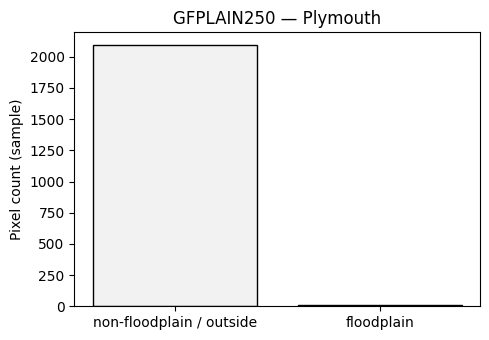

In [6]:
# Class summary for GFPLAIN (binary floodplain mask — not depth)
import numpy as np
import matplotlib.pyplot as plt

# gfplain: masked outside floodplain in many EE presentations; use presence/absence in ROI
_fp = gfplain_1.unmask(0).clip(roi)
_hist = _fp.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=roi,
    scale=250,
    maxPixels=1e10,
    bestEffort=True,
).getInfo()
print("GFPLAIN class histogram (approx.):", _hist)

_sample = _fp.sample(region=roi, scale=250, numPixels=5000, seed=42, geometries=False)
_vals = np.array(_sample.aggregate_array("gfplain_1").getInfo(), dtype=float)
_vals = _vals[np.isfinite(_vals)]
share_fp = float((_vals >= 0.5).mean()) if _vals.size else float("nan")
print(f"Sampled pixels: {_vals.size} | floodplain share ≈ {100*share_fp:.1f}%")

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = [(_vals < 0.5).sum(), (_vals >= 0.5).sum()] if _vals.size else [0, 0]
ax.bar(["non-floodplain / outside", "floodplain"], counts, color=["#f2f2f2", "#08306b"], edgecolor="k")
ax.set_ylabel("Pixel count (sample)")
ax.set_title(f"GFPLAIN250 — {SITE_CONFIG['display_name']}")
plt.tight_layout()
plt.show()


In [7]:
# Map visualization to corroborate ROI extraction
m = geemap.Map()
m.centerObject(roi, 11)
# Most implementations use 0/1 floodplain values.
# Palette: 0 (non-floodplain) = light gray, 1 (floodplain) = dark blue.
gfplain_vis = {
    'min': 0,
    'max': 1,
    'palette': ['f2f2f2', '08306b']
}
m.addLayer(gfplain, gfplain_vis, 'GFPLAIN250 (ROI)')
m.addLayer(ee.Image().paint(roi, 1, 2), {'palette': ['red']}, 'ROI boundary')
# Add legend for visual interpretation
m.add_legend(
    title='GFPLAIN250 class',
    keys=['0 = non-floodplain', '1 = floodplain'],
    colors=['#f2f2f2', '#08306b'],
    position='bottomright'
)
m

Map(center=[45.02238616047533, -93.4615216182928], controls=(WidgetControl(options=['position', 'transparent_b…

In [8]:
# --- Export GFPLAIN250m to site input/ (local by default) ---
# Override: export GEE_EXPORT_MODE=drive

from gee_local_export import export_image_to_input

scale_m = 250
crs = "EPSG:4326"
drive_folder = "OEF_GFPLAIN250"

export_image_to_input(
    gfplain_1,
    filename=SITE_CONFIG["layers"]["gfplain"],
    region=roi,
    scale=scale_m,
    input_dir=INPUT_DIR,
    crs=crs,
    description=f"gfplain_250m_{OUTPUT_PREFIX}",
    drive_folder=drive_folder,
)

print("Exports complete. Files land under:", INPUT_DIR)


[local] exporting gfplain_250m_plymouth.tif → /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfplain_250m_plymouth.tif (scale=250m, crs=EPSG:4326)
Generating URL ...
Please wait ...
Data downloaded to /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfplain_250m_plymouth.tif
[local] wrote /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input/gfplain_250m_plymouth.tif (0.00 MB)
Exports complete. Files land under: /Users/admin/Desktop/OEF/geospatial-data/transformation/flood_hazard/sites/plymouth/data/input


#### Convert GFPLAIN250m to COG and Generate Tiles

Publish the local `sites/<site_slug>/data/input/gfplain_250m_poa.tif` raster for web maps: COG + colorized XYZ tiles + value-encoded XYZ tiles for hover lookup.

Requires GDAL CLI (`gdal_translate`, `gdaldem`, `gdal_calc.py`, `gdal2tiles.py`) and `data/gfplain_250m_colors.txt`.


In [ ]:
# Convert GFPLAIN250m GeoTIFF to COG + visual tiles + value tiles
# Input expected after downloading the Earth Engine export from Google Drive.
from pathlib import Path
import shutil
import subprocess


PROJECT_ROOT = FLOODS_ROOT
in_tif = INPUT_DIR / SITE_CONFIG["layers"]["gfplain"]
out_dir = OUT_ROOT / "gfplain_250m"
colors_txt = STYLES_DIR / "gfplain_250m_colors.txt"

slug = "gfplain_250m"
cog_tif = out_dir / f"{slug}_cog.tif"
colorized_tif = out_dir / f"{slug}_colorized.tif"
value_encoded_tif = out_dir / f"{slug}_value_encoded_rgb.tif"
tiles_dir = out_dir / "tiles_visual"
value_tiles_dir = out_dir / "tiles_values"
decode_txt = out_dir / f"{slug}_value_tiles_decode.txt"

out_dir.mkdir(parents=True, exist_ok=True)
if not in_tif.exists():
    raise FileNotFoundError(f"Missing input raster: {in_tif}")
if not colors_txt.exists():
    raise FileNotFoundError(f"Missing color table: {colors_txt}")

print("Input:", in_tif)
print("Output dir:", out_dir)

# 1) COG preserving raw binary floodplain values.
subprocess.run([
    "gdal_translate", str(in_tif), str(cog_tif),
    "-of", "COG",
    "-ot", "Float32",
    "-co", "COMPRESS=DEFLATE",
    "-co", "RESAMPLING=NEAREST",
    "-co", "OVERVIEWS=AUTO",
], check=True)
print("Created COG:", cog_tif)

# 2) Colorized raster + visual XYZ tiles.
subprocess.run([
    "gdaldem", "color-relief",
    str(cog_tif), str(colors_txt), str(colorized_tif),
    "-alpha",
], check=True)
print("Created colorized raster:", colorized_tif)

# gdal2tiles preflight: use the Python interpreter referenced by gdal2tiles.py.
gdal2tiles = shutil.which("gdal2tiles.py")
if not gdal2tiles:
    raise RuntimeError("gdal2tiles.py not found in PATH. Install GDAL (e.g. brew install gdal).")

gdal2tiles_python = None
with open(gdal2tiles, "r", encoding="utf-8", errors="ignore") as f:
    first_line = f.readline().strip()
if first_line.startswith("#!"):
    shebang_parts = first_line[2:].split()
    if shebang_parts:
        if shebang_parts[0].endswith("env") and len(shebang_parts) > 1:
            gdal2tiles_python = shutil.which(shebang_parts[1])
        else:
            gdal2tiles_python = shebang_parts[0]
if not gdal2tiles_python:
    gdal2tiles_python = shutil.which("python3") or shutil.which("python")
subprocess.run([gdal2tiles_python, "-c", "import numpy"], check=True, capture_output=True)

tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    "gdal2tiles.py",
    "-r", "near",
    "-z", "8-15",
    "--xyz",
    "-w", "none",
    str(colorized_tif),
    str(tiles_dir),
], check=True)
print("Visual tiles:", tiles_dir)

# 3) Value tiles for client-side hover.
# Encodes integer values plus 1 so encoded RGB value 0 can mean nodata.
# Decode: encoded = R + 256*G + 65536*B; value = encoded - 1; encoded == 0 => nodata.
base_expr = (
    "numpy.where(numpy.isnan(A), 0, "
    "numpy.rint(numpy.clip(A,0,16777214)).astype(numpy.int64) + 1)"
)
subprocess.run([
    "gdal_calc.py",
    "-A", str(cog_tif),
    "--calc", f"bitwise_and({base_expr},255)",
    "--calc", f"bitwise_and(right_shift({base_expr},8),255)",
    "--calc", f"bitwise_and(right_shift({base_expr},16),255)",
    "--type", "Byte",
    "--NoDataValue", "0",
    "--overwrite",
    "--outfile", str(value_encoded_tif),
], check=True)

value_tiles_dir.mkdir(parents=True, exist_ok=True)
subprocess.run([
    "gdal2tiles.py",
    "-r", "near",
    "-z", "8-15",
    "--xyz",
    "-w", "none",
    str(value_encoded_tif),
    str(value_tiles_dir),
], check=True)

metadata = """GFPLAIN250m value tiles

Source raster: sites/<site_slug>/data/input/gfplain_250m_poa.tif
COG: sites/<site_slug>/out/gfplain_250m/gfplain_250m_cog.tif
Visual tiles: sites/<site_slug>/out/gfplain_250m/tiles_visual/{z}/{x}/{y}.png
Value tiles: sites/<site_slug>/out/gfplain_250m/tiles_values/{z}/{x}/{y}.png

Value tile encoding:
encoded = R + 256 * G + 65536 * B
if encoded == 0: value is nodata
else: value = encoded - 1

GFPLAIN250m values:
1 = floodplain pixel
"""
decode_txt.write_text(metadata, encoding="utf-8")

print("Value tiles:", value_tiles_dir)
print("Decode metadata:", decode_txt)
print("Decode: encoded = R + 256*G + 65536*B; value = encoded - 1; encoded 0 = nodata")
